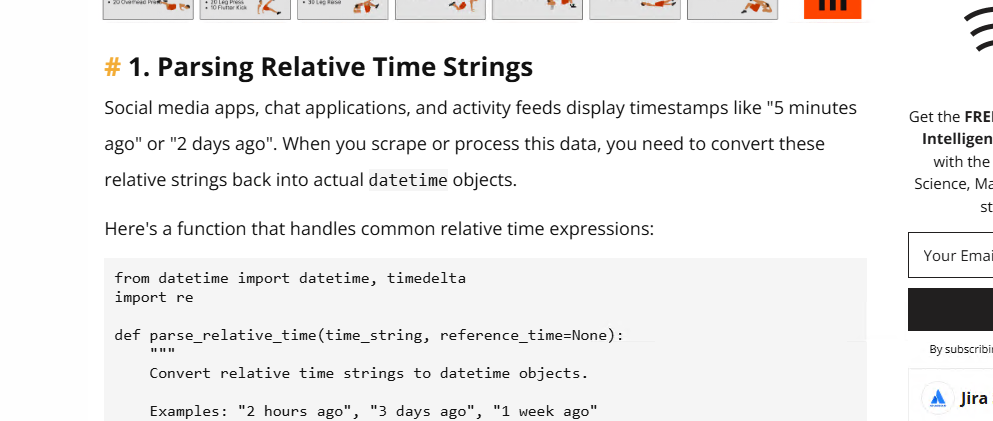

In [1]:
from datetime import datetime, timedelta
import re

def parse_relative_time(time_string, reference_time=None):
    """   Covert relative time strings to datetime objects
    Examples: "2 hours ago", "3 days ago", "1 week ago"
    """

    if reference_time is None:
        reference_time = datetime.now()

    # Normalize the string
    time_string = time_string.lower().strip()

    # Pattern: number + time unit + "ago"
    pattern = r'(\d+)\s*(second|minute|hour|day|week|month|year)s?\s*ago'
    match = re.match(pattern, time_string)

    if not match:
        raise ValueError(f"Cannot parse: {time_string}")
    
    amount = int(match.group(1))
    unit = match.group(2)

    #Map units to timedelta kwargs
    unit_mapping = {
        'second' : 'seconds',
        'minute' : 'minutes',
        'hour' : 'hours',
        'day' : 'days',
        'week' : 'weeks',
    }

    if unit in unit_mapping:
        delta_kwargs = {unit_mapping[unit]: amount}
        return reference_time - timedelta(**delta_kwargs)
    elif unit == 'month':
        # Approximate: 30 days per month
        return reference_time - timedelta(days=amount * 30)
    elif unit == 'year':
        # Approximate: 365 days per year
        return reference_time - timedelta(days=amount * 365)







In [2]:
result1 = parse_relative_time("2 hours ago")
result2 = parse_relative_time("3 days ago")
result3 = parse_relative_time("1 week ago")

print(f"2 hours ago: {result1}")
print(f"3 days ago: {result2}")
print(f"1 week ago: {result3}")

2 hours ago: 2026-01-28 18:47:05.850639
3 days ago: 2026-01-25 20:47:05.851048
1 week ago: 2026-01-21 20:47:05.851110
